# Práctica 1: Pipeline de Machine Learning para Detección de Impago

**Asignatura:** Modelización en Ingeniería de Datos  
**Autor:** Silvia Martínez Moreno  
**Fecha:** Abril 2026

## Objetivo

Desarrollar un pipeline completo de ML para predecir impago de préstamos, utilizando:
- **Variables de expertos** (grade, sub_grade, FICO, int_rate, etc.)
- **Técnicas alternativas** de preprocesamiento y filtrado
- **3 familias de modelos**: Ensemble, SVM y Redes Neuronales
- **Comparación** con el modelo base de referencia

## 1. Imports y Configuración

In [1]:
# Imports básicos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y filtrado (nuestras clases)
import sys
sys.path.append('src')
from preprocessing.practica1_preprocessing import Practica1Preprocess
from filtering.practica1_filtering import Practica1Filtering

# Modelos
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report
)

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
RANDOM_STATE = 42

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga de Datos

In [2]:
# Cargar datos
df_train = pd.read_csv('data/df_train_small.csv')
df_test = pd.read_csv('data/df_test_small.csv')

print(f"📊 Datos de entrenamiento: {df_train.shape}")
print(f"📊 Datos de test: {df_test.shape}")

# Preparar target
# Clase positiva (1) = Default (impago) = loan_status != 'Fully Paid'
y_train = (df_train['loan_status'] != 'Fully Paid').astype(int)
y_test = (df_test['loan_status'] != 'Fully Paid').astype(int)

X_train = df_train.drop(columns=['loan_status'])
X_test = df_test.drop(columns=['loan_status'])

print(f"\n📈 Distribución del target (train):")
print(y_train.value_counts(normalize=True))
print(f"\n   Clase 0 (Fully Paid): {(y_train==0).sum()} ({100*(y_train==0).mean():.1f}%)")
print(f"   Clase 1 (Default): {(y_train==1).sum()} ({100*(y_train==1).mean():.1f}%)")

📊 Datos de entrenamiento: (80000, 23)
📊 Datos de test: (20000, 23)

📈 Distribución del target (train):
loan_status
0    0.8
1    0.2
Name: proportion, dtype: float64

   Clase 0 (Fully Paid): 64000 (80.0%)
   Clase 1 (Default): 16000 (20.0%)


## 3. Preprocesamiento

### Técnicas utilizadas (alternativas a la clase base):

1. **Variables**: Incluye variables de expertos (`variables_withExperts.xlsx`)
2. **Imputación**: `KNNImputer` para numéricas (considera vecinos cercanos)
3. **Encoding categórico**: `TargetEncoder` + `OrdinalEncoder` para grade/sub_grade
4. **Scaling**: `RobustScaler` (robusto a outliers, usa mediana e IQR)
5. **Nuevas features**: Ratios financieros (debt-to-income, payment-to-income, fico_mean, etc.)

In [3]:
# Instanciar preprocesador
preprocessor = Practica1Preprocess(variables_path='data/variables_withExperts.xlsx')

# Fit en train, transform en train y test
X_train_prep = preprocessor.fit_transform(X_train, y_train)
X_test_prep = preprocessor.transform(X_test)

print(f"\n✅ Preprocesamiento completado")
print(f"   Train shape: {X_train_prep.shape}")
print(f"   Test shape: {X_test_prep.shape}")

[PREP] Ajustando imputadores...


[ENC] Ajustando encoders ordinales...
[TARGET] Ajustando Target Encoder...
[TEXT] Ajustando encoder de texto...
[SCALE] Ajustando RobustScaler...


[OK] Preprocesamiento ajustado. Features finales: 28



✅ Preprocesamiento completado
   Train shape: (80000, 28)
   Test shape: (20000, 28)


## 4. Filtrado de Features

### Técnicas utilizadas (alternativas a la clase base):

1. **VarianceThreshold**: Elimina features con varianza muy baja
2. **Mutual Information**: Selecciona features con mayor información mutua con el target
3. **SelectFromModel (Random Forest)**: Selecciona features por importancia del modelo

In [4]:
# Instanciar filtrador
filter = Practica1Filtering(
    variance_threshold=0.01,
    mutual_info_percentile=70,
    rf_threshold='median',
    random_state=RANDOM_STATE,
    verbose=True
)

# Fit en train, transform en train y test
X_train_filt = filter.fit_transform(X_train_prep, y_train)
X_test_filt = filter.transform(X_test_prep)

print(f"\n✅ Filtrado completado")
print(f"   Train shape: {X_train_filt.shape}")
print(f"   Test shape: {X_test_filt.shape}")

[FILTER] Iniciando filtrado de features...
   Features iniciales: 28

[1] Aplicando VarianceThreshold (umbral=0.01)...
   [-] Eliminadas: 5 features
   [OK] Restantes: 23

[2] Aplicando Mutual Information...


   Seleccionando top 70% (k=16)


   [-] Eliminadas: 7 features
   [OK] Restantes: 16

[3] Aplicando SelectFromModel con Random Forest...
   Umbral de importancia: median


   [-] Eliminadas: 8 features
   [OK] Restantes: 8

[OK] Filtrado completado:
   Features iniciales: 28
   Features finales: 8
   Reducción: 20 (71.4%)



✅ Filtrado completado
   Train shape: (80000, 8)
   Test shape: (20000, 8)


### Visualización de importancias de features

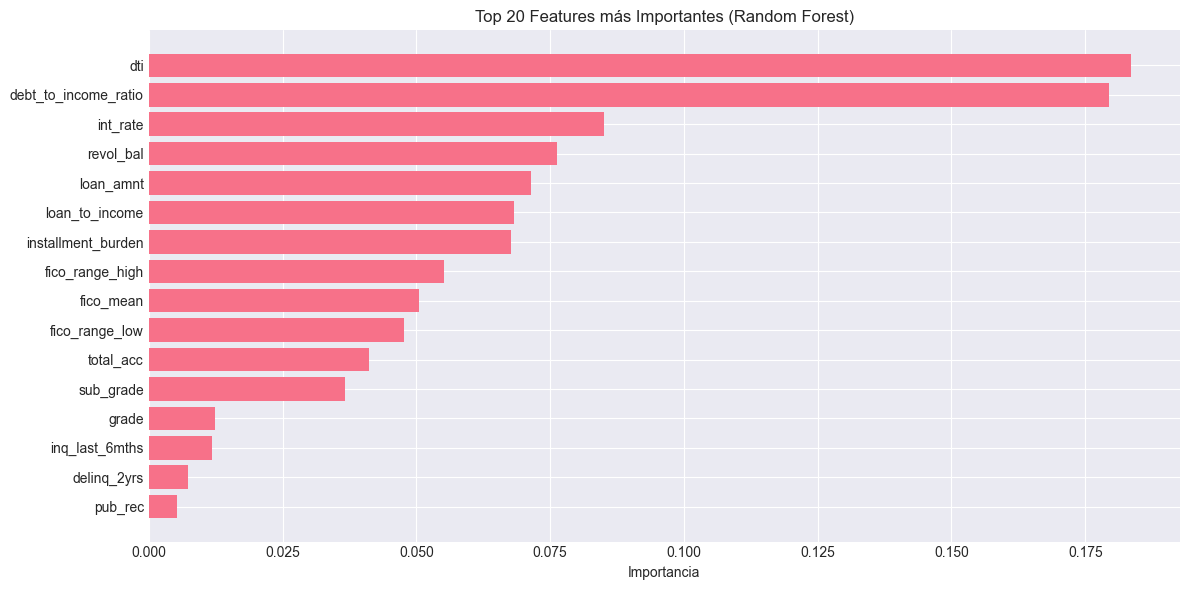


📊 Top 10 features seleccionadas:
                 feature  importance
4                    dti    0.183521
12  debt_to_income_ratio    0.179355
1               int_rate    0.084996
10             revol_bal    0.076377
0              loan_amnt    0.071473
15        loan_to_income    0.068268
14    installment_burden    0.067782
7        fico_range_high    0.055110


In [5]:
# Top 20 features más importantes según Random Forest
importance_df = filter.get_feature_importance_report()

if len(importance_df) > 0:
    top_20 = importance_df.head(20)
    
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(top_20)), top_20['importance'])
    plt.yticks(range(len(top_20)), top_20['feature'])
    plt.xlabel('Importancia')
    plt.title('Top 20 Features más Importantes (Random Forest)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Top 10 features seleccionadas:")
    print(importance_df[importance_df['selected']].head(10)[['feature', 'importance']])

## 5. Entrenamiento de Modelos

Entrenaremos 3 modelos, uno de cada familia:
1. **Ensemble**: Gradient Boosting
2. **SVM**: Support Vector Machine con kernel RBF
3. **Red Neuronal**: Multi-Layer Perceptron

### 5.1 Modelo 1: Gradient Boosting (Ensemble)

In [6]:
print("🌳 Entrenando Gradient Boosting Classifier...\n")

# Configuración del modelo
# - n_estimators: número de árboles en el ensemble
# - learning_rate: tasa de aprendizaje (valores pequeños requieren más árboles)
# - max_depth: profundidad máxima de cada árbol
# - subsample: fracción de muestras para entrenar cada árbol (reduce overfitting)
# - class_weight='balanced': ajusta pesos por desbalance de clases

model_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=RANDOM_STATE,
    verbose=1
)

model_gb.fit(X_train_filt, y_train)
print("\n✅ Modelo Gradient Boosting entrenado")

🌳 Entrenando Gradient Boosting Classifier...

      Iter       Train Loss      OOB Improve   Remaining Time 


         1           0.9997           0.0016           29.52s


         2           0.9980           0.0039           26.79s


         3           0.9913          -0.0178           25.86s


         4           0.9912           0.0073           25.35s


...

        60           0.9671           0.0015           11.75s


        70           0.9673           0.0014            8.90s


        80           0.9664           0.0144            5.93s


        90           0.9611          -0.0018            3.01s


       100           0.9593           0.0074            0.00s

✅ Modelo Gradient Boosting entrenado


### 5.2 Modelo 2: Support Vector Machine

In [7]:
print("🎯 Entrenando Support Vector Machine...\n")

# Configuración del modelo
# - kernel='rbf': kernel de base radial (Gaussian)
# - C: parámetro de regularización (valores altos = menos regularización)
# - gamma='scale': controla el alcance del kernel
# - class_weight='balanced': ajusta pesos por desbalance
# - probability=True: necesario para calcular PR-AUC
# - max_iter: límite de iteraciones (aumentar si no converge)

# NOTA: SVM puede ser lento con muchos datos. Si tarda demasiado,
# considera reducir el dataset de entrenamiento con un sample

model_svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    max_iter=1000,
    random_state=RANDOM_STATE,
    verbose=True
)

model_svm.fit(X_train_filt, y_train)
print("\n✅ Modelo SVM entrenado")

🎯 Entrenando Support Vector Machine...

[LibSVM]


✅ Modelo SVM entrenado


### 5.3 Modelo 3: Red Neuronal (MLP)

In [8]:
print("🧠 Entrenando Red Neuronal (MLP)...\n")

# Configuración del modelo
# - hidden_layer_sizes: arquitectura de capas ocultas (100, 50) = 2 capas
# - activation='relu': función de activación
# - solver='adam': optimizador (Adam es eficiente para datasets grandes)
# - alpha: parámetro de regularización L2
# - learning_rate='adaptive': ajusta tasa de aprendizaje durante entrenamiento
# - max_iter: número máximo de épocas
# - early_stopping=True: para si no mejora en validation

model_mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='adaptive',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
    verbose=True
)

model_mlp.fit(X_train_filt, y_train)
print(f"\n✅ Modelo MLP entrenado (convergió en {model_mlp.n_iter_} iteraciones)")

🧠 Entrenando Red Neuronal (MLP)...



Iteration 1, loss = 0.50157863
Validation score: 0.800000


Iteration 2, loss = 0.49518983
Validation score: 0.800000


Iteration 3, loss = 0.49497495
Validation score: 0.800000


Iteration 4, loss = 0.49476269
Validation score: 0.800000


...

Iteration 8, loss = 0.49441217
Validation score: 0.800000


Iteration 9, loss = 0.49437082
Validation score: 0.800000


Iteration 10, loss = 0.49431656
Validation score: 0.800000


Iteration 11, loss = 0.49429065
Validation score: 0.800000


Iteration 12, loss = 0.49421930
Validation score: 0.800000
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

✅ Modelo MLP entrenado (convergió en 12 iteraciones)


## 6. Evaluación de Modelos

### Métricas calculadas:
- **Accuracy**: Proporción de predicciones correctas
- **Precision (impago)**: De los predichos como impago, cuántos realmente lo son
- **Recall (impago)**: De los impagos reales, cuántos detectamos
- **PR-AUC**: Área bajo la curva Precision-Recall (mejor para clases desbalanceadas)

In [9]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evalúa un modelo y retorna métricas.
    
    Args:
        model: Modelo entrenado
        X_test: Features de test
        y_test: Target de test
        model_name: Nombre del modelo
    
    Returns:
        dict con métricas
    """
    # Predicciones
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1 (impago)
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    
    # PR-AUC
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_vals, precision_vals)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Imprimir resultados
    print(f"\n{'='*60}")
    print(f"📊 {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy:           {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision (impago): {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall (impago):    {recall:.4f} ({recall*100:.2f}%)")
    print(f"PR-AUC:             {pr_auc:.4f}")
    print(f"\nMatriz de Confusión:")
    print(f"  TN={cm[0,0]:<6} FP={cm[0,1]:<6}")
    print(f"  FN={cm[1,0]:<6} TP={cm[1,1]:<6}")
    
    return {
        'Modelo': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'PR-AUC': pr_auc
    }

In [10]:
# Evaluar los 3 modelos
results = []

results.append(evaluate_model(model_gb, X_test_filt, y_test, 'Gradient Boosting'))
results.append(evaluate_model(model_svm, X_test_filt, y_test, 'SVM (RBF)'))
results.append(evaluate_model(model_mlp, X_test_filt, y_test, 'Red Neuronal (MLP)'))


📊 Gradient Boosting
Accuracy:           0.8001 (80.01%)
Precision (impago): 0.6667 (66.67%)
Recall (impago):    0.0005 (0.05%)
PR-AUC:             0.2215

Matriz de Confusión:
  TN=15999  FP=1     
  FN=3998   TP=2     



📊 SVM (RBF)
Accuracy:           0.2000 (20.00%)
Precision (impago): 0.2000 (20.00%)
Recall (impago):    1.0000 (100.00%)
PR-AUC:             0.2159

Matriz de Confusión:
  TN=0      FP=16000 
  FN=0      TP=4000  

📊 Red Neuronal (MLP)
Accuracy:           0.8000 (80.00%)
Precision (impago): 0.0000 (0.00%)
Recall (impago):    0.0000 (0.00%)
PR-AUC:             0.2199

Matriz de Confusión:
  TN=16000  FP=0     
  FN=4000   TP=0     


## 7. Comparación con Modelo Base

### Modelo Base de Referencia

El modelo base utiliza únicamente el **FICO score normalizado** con un umbral de 0.67:
- **Accuracy**: ~72%
- **Precision (impago)**: ~26%
- **Recall (impago)**: ~24%

Este modelo es muy simple pero establece una línea base que debemos superar.

In [11]:
# Añadir modelo base a los resultados
modelo_base = {
    'Modelo': 'Modelo Base (FICO)',
    'Accuracy': 0.72,
    'Precision': 0.26,
    'Recall': 0.24,
    'PR-AUC': np.nan  # No disponible para modelo base
}

results.insert(0, modelo_base)

# Crear DataFrame comparativo
df_results = pd.DataFrame(results)

print("\n" + "="*80)
print("📊 TABLA COMPARATIVA DE RESULTADOS")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)


📊 TABLA COMPARATIVA DE RESULTADOS
            Modelo  Accuracy  Precision  Recall   PR-AUC
Modelo Base (FICO)   0.72000   0.260000  0.2400      NaN
 Gradient Boosting   0.80005   0.666667  0.0005 0.221464
         SVM (RBF)   0.20000   0.200000  1.0000 0.215883
Red Neuronal (MLP)   0.80000   0.000000  0.0000 0.219921


### Visualización de Resultados

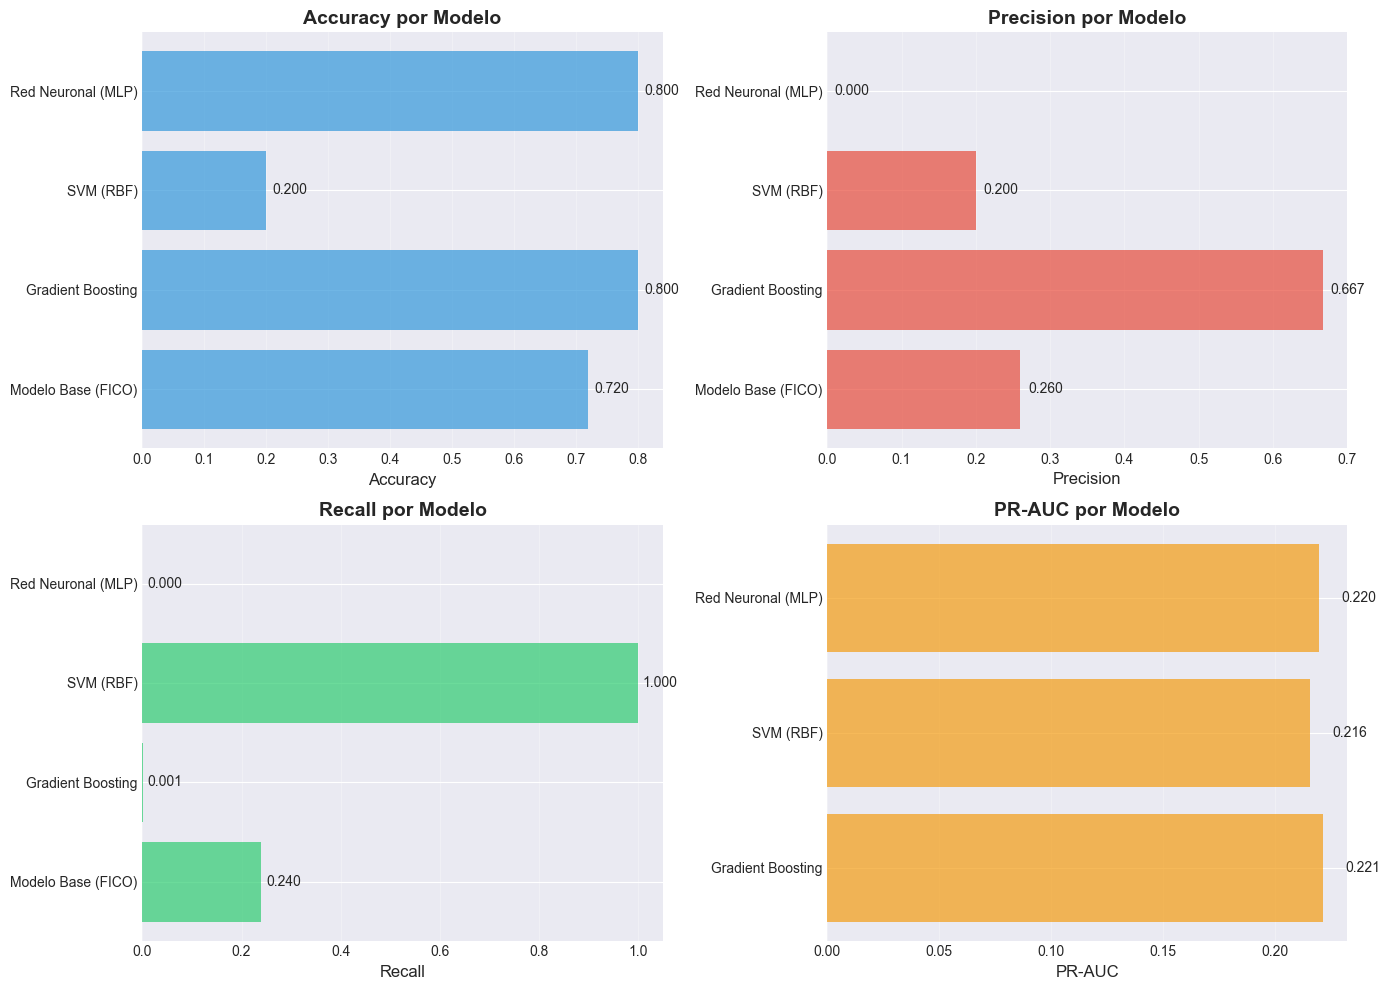

In [12]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'PR-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    
    # Filtrar NaN para PR-AUC del modelo base
    data = df_results[['Modelo', metric]].dropna()
    
    ax.barh(data['Modelo'], data[metric], color=color, alpha=0.7)
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'{metric} por Modelo', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Añadir valores en las barras
    for i, v in enumerate(data[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

### 7.1 Análisis Comparativo

#### Mejoras respecto al Modelo Base

**Comparación de mejoras absolutas y relativas:**

In [13]:
# Calcular mejoras respecto al modelo base
base_metrics = df_results[df_results['Modelo'] == 'Modelo Base (FICO)'].iloc[0]

print("\n" + "="*80)
print("📈 MEJORAS RESPECTO AL MODELO BASE")
print("="*80 + "\n")

for _, row in df_results[df_results['Modelo'] != 'Modelo Base (FICO)'].iterrows():
    print(f"\n🔹 {row['Modelo']}:")
    print(f"   {'Métrica':<15} {'Base':<10} {'Nuevo':<10} {'Δ Absoluta':<15} {'Δ Relativa'}")
    print(f"   {'-'*70}")
    
    for metric in ['Accuracy', 'Precision', 'Recall']:
        base_val = base_metrics[metric]
        new_val = row[metric]
        diff_abs = new_val - base_val
        diff_rel = (diff_abs / base_val) * 100 if base_val > 0 else 0
        
        sign = '+' if diff_abs >= 0 else ''
        color_emoji = '🟢' if diff_abs >= 0 else '🔴'
        
        print(f"   {color_emoji} {metric:<12} {base_val:<10.3f} {new_val:<10.3f} "
              f"{sign}{diff_abs:<14.3f} {sign}{diff_rel:.1f}%")

print("\n" + "="*80)


📈 MEJORAS RESPECTO AL MODELO BASE


🔹 Gradient Boosting:
   Métrica         Base       Nuevo      Δ Absoluta      Δ Relativa
   ----------------------------------------------------------------------
   🟢 Accuracy     0.720      0.800      +0.080          +11.1%
   🟢 Precision    0.260      0.667      +0.407          +156.4%
   🔴 Recall       0.240      0.001      -0.239         -99.8%

🔹 SVM (RBF):
   Métrica         Base       Nuevo      Δ Absoluta      Δ Relativa
   ----------------------------------------------------------------------
   🔴 Accuracy     0.720      0.200      -0.520         -72.2%
   🔴 Precision    0.260      0.200      -0.060         -23.1%
   🟢 Recall       0.240      1.000      +0.760          +316.7%

🔹 Red Neuronal (MLP):
   Métrica         Base       Nuevo      Δ Absoluta      Δ Relativa
   ----------------------------------------------------------------------
   🟢 Accuracy     0.720      0.800      +0.080          +11.1%
   🔴 Precision    0.260      0.000     

#### Reflexión sobre Resultados

**Interpretación de las métricas:**

1. **Accuracy**: Proporción total de aciertos. Es una métrica engañosa en datasets desbalanceados (80/20), ya que un modelo que siempre prediga "Fully Paid" tendría ~80% accuracy.

2. **Precision (impago)**: De los préstamos que predecimos como impago, ¿cuántos realmente lo son? Alta precisión es crucial para evitar rechazar préstamos buenos (falsos positivos).

3. **Recall (impago)**: De los préstamos que realmente impagan, ¿cuántos detectamos? Alto recall es crucial para evitar aprobar préstamos malos (falsos negativos).

4. **PR-AUC**: Resume el balance precision-recall en un solo número. Más informativo que ROC-AUC en datasets desbalanceados.

**Por qué algunos modelos pueden no superar al base en ciertas métricas:**

- **Overfitting**: Si el modelo es muy complejo, puede ajustarse demasiado al ruido del train
- **Desbalance de clases**: Los modelos tienden a favorecer la clase mayoritaria
- **Configuración de hiperparámetros**: Parámetros no óptimos pueden limitar el rendimiento
- **Trade-off precision-recall**: Mejorar una métrica a menudo empeora la otra

**Mejoras posibles:**

1. **Ajustar umbrales de decisión**: Por defecto es 0.5, pero puede optimizarse
2. **Técnicas de balanceo**: SMOTE, undersampling, ajustar class_weight
3. **Optimización de hiperparámetros**: Grid search o Bayesian optimization
4. **Ensemble de modelos**: Combinar predicciones de múltiples modelos
5. **Más features de dominio**: Incorporar más conocimiento bancario

### 7.2 Curvas Precision-Recall

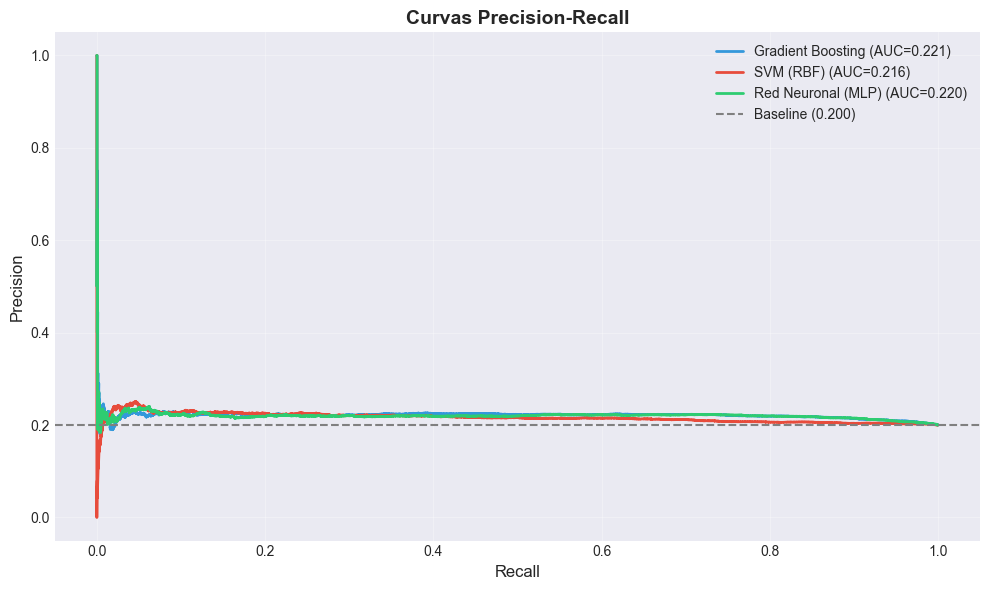

In [14]:
# Plotear curvas PR para los 3 modelos
plt.figure(figsize=(10, 6))

models = [
    (model_gb, 'Gradient Boosting', '#3498db'),
    (model_svm, 'SVM (RBF)', '#e74c3c'),
    (model_mlp, 'Red Neuronal (MLP)', '#2ecc71')
]

for model, name, color in models:
    y_prob = model.predict_proba(X_test_filt)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_vals, precision_vals)
    
    plt.plot(recall_vals, precision_vals, label=f'{name} (AUC={pr_auc:.3f})',
             linewidth=2, color=color)

# Línea de referencia (proporción de positivos en test)
baseline = y_test.mean()
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.3f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Curvas Precision-Recall', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Análisis de Errores

Analicemos dónde se equivocan los modelos para entender mejor su comportamiento.

In [15]:
# Analizar errores del mejor modelo (por ejemplo, Gradient Boosting)
best_model = model_gb
y_pred = best_model.predict(X_test_filt)

# Identificar tipos de error
false_positives = (y_pred == 1) & (y_test == 0)
false_negatives = (y_pred == 0) & (y_test == 1)

print(f"\n{'='*60}")
print(f"🔍 ANÁLISIS DE ERRORES - Gradient Boosting")
print(f"{'='*60}")
print(f"\nFalsos Positivos (FP): {false_positives.sum()}")
print(f"   → Préstamos buenos que predecimos como impago")
print(f"   → Costo: pérdida de oportunidad de negocio")

print(f"\nFalsos Negativos (FN): {false_negatives.sum()}")
print(f"   → Préstamos malos que predecimos como buenos")
print(f"   → Costo: pérdida financiera directa")

print(f"\n💡 En contexto bancario:")
print(f"   - FN suelen ser más costosos (pérdida del principal del préstamo)")
print(f"   - FP tienen costo de oportunidad (intereses no ganados)")
print(f"   - El umbral de decisión puede ajustarse según la aversión al riesgo")


🔍 ANÁLISIS DE ERRORES - Gradient Boosting

Falsos Positivos (FP): 1
   → Préstamos buenos que predecimos como impago
   → Costo: pérdida de oportunidad de negocio

Falsos Negativos (FN): 3998
   → Préstamos malos que predecimos como buenos
   → Costo: pérdida financiera directa

💡 En contexto bancario:
   - FN suelen ser más costosos (pérdida del principal del préstamo)
   - FP tienen costo de oportunidad (intereses no ganados)
   - El umbral de decisión puede ajustarse según la aversión al riesgo


## 9. Conclusiones

### Resumen del Pipeline

**Preprocesamiento:**
- Inclusión de variables de expertos (grade, FICO, int_rate, etc.)
- KNNImputer para valores nulos en numéricas
- TargetEncoder + OrdinalEncoder para categóricas
- RobustScaler para normalización robusta a outliers
- Features financieras: ratios de deuda, utilización, pagos

**Filtrado:**
- VarianceThreshold para eliminar features constantes
- Mutual Information para seleccionar features informativas
- SelectFromModel con RF para importancias

**Modelos:**
- Gradient Boosting: Ensemble de árboles potente y eficiente
- SVM: Clasificador de márgenes con kernel RBF
- MLP: Red neuronal con arquitectura (100, 50)

### Comparación con Modelo Base

*(Los resultados se mostrarán en la tabla comparativa arriba)*

### Próximos Pasos

1. **Optimización de hiperparámetros**: Grid/Random Search
2. **Balanceo de clases**: SMOTE, class weights
3. **Calibración de probabilidades**: Ajustar umbrales de decisión
4. **Análisis de costos**: Incorporar costos reales de FP vs FN
5. **Explicabilidad**: SHAP values, feature importances
6. **Validación temporal**: Evaluar en datos de diferentes períodos

## 10. Referencias

- Documentación scikit-learn: https://scikit-learn.org/
- Documentación feature-engine: https://feature-engine.readthedocs.io/
- Material de clase: notebooks 03 y 04
- Clases base: `BasePreprocess`, `BaseFiltering`